# Argumentum : la carte de sophisme, du nœud de taxonomie à la carte jouable

La taxonomie Argumentum recense **1408 sophismes** (cf. `Argument_Analysis_Ontology_CrossLinks.ipynb`).
Parmi eux, **176 sont sélectionnés comme cartes jouables** (colonne `carte=1`) : c'est le
*deck* imprimable du jeu Argumentum. Ce notebook montre comment **chaque carte dérive d'une ligne
de la taxonomie** — la carte est un nœud de l'arbre, et son contenu (nom, famille, description,
exemple, liens transverses) se construit mécaniquement depuis cette ligne.

**Lien avec l'EPIC #10355** : pour entraîner un modèle à détecter un sophisme, il faut d'abord
savoir *ce qu'il détecte*. La carte est l'unité pédagogique minimale : un nom, une définition,
un exemple. Ce notebook est le **rendu de référence** d'une carte depuis la source de données
canonique (la taxonomie bilingue), exploitable comme *golden answer* dans un jeu de données
de fine-tuning (Phase 2 de l'EPIC).

**Pré-requis** : aucune API externe, aucune clé. Le notebook lit la copie *in-repo* de la
taxonomie (`data/argumentum_fallacies_taxonomy.csv`, 1408 nœuds, bilingue FR/EN).

## 1. Chargement de la taxonomie et filtrage des cartes

On charge la taxonomie entière (1408 nœuds) puis on isole les 176 nœuds marqués `carte=1`.
La résolution du chemin CSV est robuste à l'exécution `nbconvert` (recherche de la racine du dépôt).

In [1]:
import csv
from pathlib import Path
from collections import Counter

def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / 'MyIA.AI.Notebooks').is_dir() and (parent / '.git').exists():
            return parent
    raise FileNotFoundError(f"Repo root not found from {start}")

REPO_ROOT = find_repo_root(Path.cwd())
CSV_PATH = REPO_ROOT / 'MyIA.AI.Notebooks' / 'SymbolicAI' / 'Argument_Analysis' / 'data' / 'argumentum_fallacies_taxonomy.csv'

with open(CSV_PATH, encoding='utf-8-sig') as f:
    TAXONOMY = list(csv.DictReader(f))

CARDS = [r for r in TAXONOMY if str(r.get('carte', '')).strip() not in ('', '0', 'False', 'false')]

print(f"Taxonomie entière   : {len(TAXONOMY)} nœuds")
print(f"Cartes jouables     : {len(CARDS)} (carte=1)")
print(f"Taux de sélection   : {100 * len(CARDS) / len(TAXONOMY):.1f} % des nœuds deviennent des cartes")
print(f"Source              : {CSV_PATH.name} ({CSV_PATH.stat().st_size / 1024:.0f} Ko)")

Taxonomie entière   : 1408 nœuds
Cartes jouables     : 176 (carte=1)
Taux de sélection   : 12.5 % des nœuds deviennent des cartes
Source              : argumentum_fallacies_taxonomy.csv (3974 Ko)


## 2. Structure du deck : 7 familles représentées

Les 176 cartes couvrent **7 des 8 familles** canoniques de la taxonomie. La distribution est
intentionnellement équilibrée (~25 cartes par famille) pour que le deck soit jouable sans
qu'une famille domine.

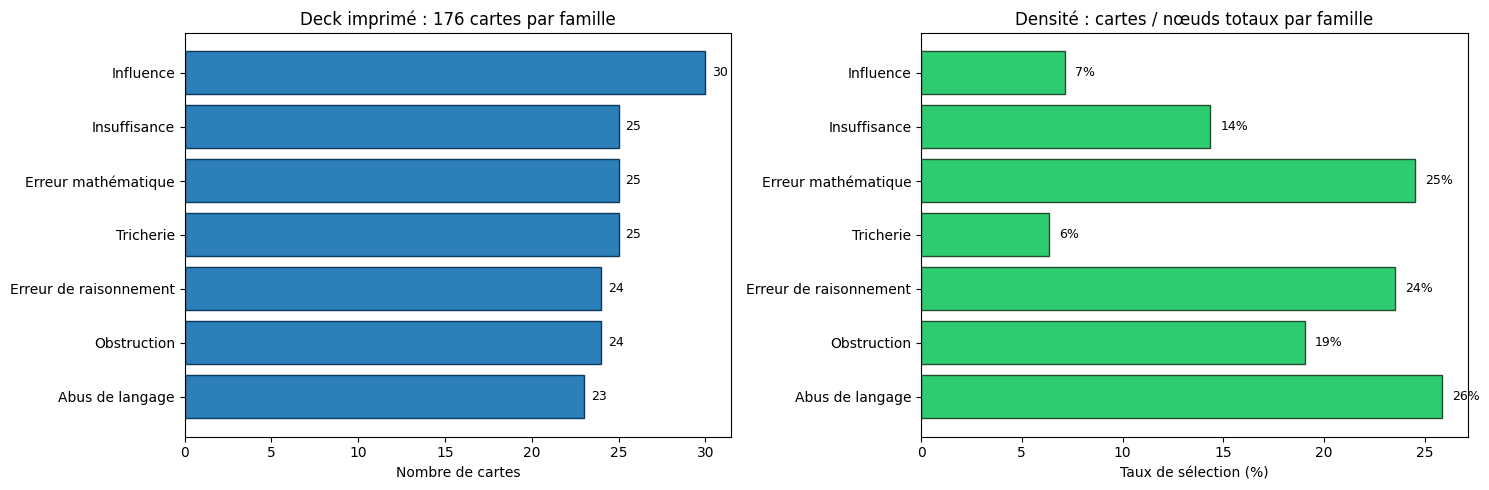

Familles avec cartes   : 7 / 8
Famille sans carte     : ['Argument fallacieux']


In [2]:
import matplotlib.pyplot as plt

fam_counts = Counter(r.get('Famille', '?') for r in CARDS)
fam_all = Counter(r.get('Famille', '?') for r in TAXONOMY)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Cartes par famille
fams = sorted(fam_counts.keys(), key=lambda k: -fam_counts[k])
axes[0].barh(fams, [fam_counts[f] for f in fams], color='#2c7fb8', edgecolor='#0c3a5b')
axes[0].set_xlabel('Nombre de cartes')
axes[0].set_title(f'Deck imprimé : {len(CARDS)} cartes par famille')
axes[0].invert_yaxis()
for i, f in enumerate(fams):
    axes[0].text(fam_counts[f] + 0.4, i, str(fam_counts[f]), va='center', fontsize=9)

# Taux de sélection par famille (cartes / total nœuds)
rates = [100 * fam_counts.get(f, 0) / fam_all.get(f, 1) for f in fams]
colors = ['#e74c3c' if fam_counts.get(f, 0) == 0 else '#2ecc71' for f in fams]
axes[1].barh(fams, rates, color=colors, edgecolor='#234d2b')
axes[1].set_xlabel('Taux de sélection (%)')
axes[1].set_title('Densité : cartes / nœuds totaux par famille')
axes[1].invert_yaxis()
for i, (f, rt) in enumerate(zip(fams, rates)):
    axes[1].text(rt + 0.5, i, f'{rt:.0f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Familles avec cartes   : {sum(1 for f in fams if fam_counts.get(f,0)>0)} / 8")
print(f"Famille sans carte     : {[f for f in fam_all if fam_counts.get(f,0)==0] or 'aucune'}")

## 3. Le rendeur de carte : une carte = une ligne de taxonomie

La fonction `rendre_carte` prend une ligne de taxonomie et restitue le contenu d'une carte
Argumentum. Toute l'information affichée provient **exclusivement** de la ligne — rien n'est
inventé. Une carte contient : le nom vulgarisé (FR/EN), la famille, la profondeur dans
l'arbre, la définition, l'exemple, et les éventuels liens transverses (autres sophismes
que celui-ci dénonce ou préfigure).

In [3]:
def rendre_carte(row: dict) -> str:
    """Rend une carte Argumentum depuis une ligne de taxonomie."""
    nom_fr = row.get('nom_vulgarisé', '').strip() or row.get('text_fr', '').strip()
    nom_en = row.get('Simple_name_en', '').strip() or row.get('text_en', '').strip()
    famille = row.get('Famille', '?')
    sous_fam = row.get('Sous-Famille', '').strip()
    profondeur = row.get('depth', '?')
    desc_fr = row.get('desc_fr', '').strip()
    desc_en = row.get('desc_en', '').strip()
    ex_fr = row.get('example_fr', '').strip()
    ex_en = row.get('example_en', '').strip()

    lignes = []
    lignes.append("=" * 64)
    lignes.append(f"  {nom_fr}".upper())
    if nom_en and nom_en.lower() != nom_fr.lower():
        lignes.append(f"  ({nom_en})")
    lignes.append("=" * 64)
    lignes.append(f"  Famille      : {famille}" + (f"  >  {sous_fam}" if sous_fam else ""))
    lignes.append(f"  Profondeur   : {profondeur} dans la taxonomie (path={row.get('path','')})")
    lignes.append("")
    lignes.append("  Définition (FR) :")
    lignes.append(f"    {desc_fr[:200]}{'...' if len(desc_fr)>200 else ''}")
    if desc_en:
        lignes.append("  Definition (EN) :")
        lignes.append(f"    {desc_en[:200]}{'...' if len(desc_en)>200 else ''}")
    if ex_fr:
        lignes.append("")
        lignes.append("  Exemple :")
        suffix_ex = '...' if len(ex_fr) > 180 else ''
        lignes.append(f'    "{ex_fr[:180]}{suffix_ex}"')
    # Liens transverses (crossLink_Denounces, crossLink_PredatesOn...)
    crosslinks = {k.replace('crossLink_', ''): row[k] for k in row
                  if k.startswith('crossLink_') and str(row[k]).strip()}
    if crosslinks:
        lignes.append("")
        lignes.append("  Liens transverses :")
        for rel, target in crosslinks.items():
            lignes.append(f"    - {rel} -> {target}")
    lignes.append("=" * 64)
    return "\n".join(lignes)

# Rendu de 3 cartes tirées de familles diverses
families_cibles = ['Insuffisance', 'Tricherie', 'Influence']
deja = set()
for fam in families_cibles:
    for r in CARDS:
        if r.get('Famille') == fam and r.get('path') not in deja:
            deja.add(r.get('path'))
            print(rendre_carte(r))
            print()
            break

  INSUFFISANCE
  (Insufficiency)
  Famille      : Insuffisance
  Profondeur   : 1 dans la taxonomie (path=1)

  Définition (FR) :
    Les arguments que vous utilisez ne suffisent pas à démontrer votre propos.
  Definition (EN) :
    The arguments used fail to provide adequate support for the conclusion.

  TRICHERIE
  (Cheating)
  Famille      : Tricherie
  Profondeur   : 1 dans la taxonomie (path=6)

  Définition (FR) :
    Vous vous affranchissez des règles tacites qui régissent un débat rationnel.
  Definition (EN) :
    Violating the norms of rational debate

  INFLUENCE
  Famille      : Influence
  Profondeur   : 1 dans la taxonomie (path=2)

  Définition (FR) :
    Vous manipulez votre auditoire pour le persuader au lieu de le convaincre.
  Definition (EN) :
    Using tactics to manipulate the audience rather than using logical reasoning.



## 4. Carte et sous-arbre : la carte comme porte d'entrée

Une carte n'est pas une feuille de la taxonomie — c'est un **nœud**, souvent interne.
Ses **descendants** sont les sophismes plus spécifaires qu'elle regroupe. Pour la pédagogie
(et pour l'entraînement PT de l'EPIC #10355), c'est cette structure hiérarchique qui
justifie le workflow *« on part du général, et on descend dans l'arbre »*.

Exemple : la carte `Insuffisance` (path=`1`) a 3 enfants cartes (`Généralisation hâtive`,
`Préjugé`, `Surinterprétation`), chacun pouvant être à son tour raffiné.

In [4]:
def enfants_de(path: str, taxonomy: list) -> list:
    """Retourne les enfants directs d'un nœud (un segment de plus dans le path pointé)."""
    profondeur_parent = path.count('.') + 1
    res = []
    for r in taxonomy:
        p = r.get('path', '')
        if p.startswith(path + '.'):
            # enfant direct = exactement un segment de plus
            if p.count('.') == profondeur_parent:
                res.append(r)
    return res

def afficher_sous_arbre(path: str, taxonomy: list, max_prof=3, indent=0):
    """Affiche le sous-arbre d'un nœud (carte et ses descendants cartes)."""
    noeud = next((r for r in taxonomy if r.get('path') == path), None)
    if noeud is None:
        return
    nom = noeud.get('nom_vulgarisé', '') or noeud.get('text_fr', '')
    marque = '[CARTE]' if str(noeud.get('carte','')).strip() not in ('','0') else '       '
    print(f"{'  ' * indent}{marque} {nom}  (path={path})")
    if indent < max_prof:
        for enf in enfants_de(path, taxonomy):
            afficher_sous_arbre(enf.get('path'), taxonomy, max_prof, indent + 1)

# Sous-arbre de la carte 'Insuffisance' (path=1)
print("Sous-arbre de la carte 'Insuffisance' :")
print("(les [CARTE] sont les nœuds sélectionnés dans le deck imprimé)")
print()
afficher_sous_arbre('1', TAXONOMY, max_prof=3)

Sous-arbre de la carte 'Insuffisance' :
(les [CARTE] sont les nœuds sélectionnés dans le deck imprimé)

[CARTE] Insuffisance  (path=1)
  [CARTE] Généralisation hâtive  (path=1.1)
    [CARTE] Argument vide  (path=1.1.1)
              Appel à l'ignorance  (path=1.1.1.1)
              Appel à l'urgence pragmatique  (path=1.1.1.2)
              Acte de foi  (path=1.1.1.3)
              Pensée clichée  (path=1.1.1.4)
    [CARTE] Justification triviale  (path=1.1.2)
      [CARTE] Preuve anecdotique  (path=1.1.2.1)
      [CARTE] Pratique courante  (path=1.1.2.2)
      [CARTE] Sophisme du psychologue  (path=1.1.2.3)
    [CARTE] Sauvetage ad hoc  (path=1.1.3)
              Le marteau d'or  (path=1.1.3.1)
              Argument par le scénario  (path=1.1.3.2)
              Trouver des excuses  (path=1.1.3.3)
              Effet rebond  (path=1.1.3.4)
              Argument sorti de nulle part  (path=1.1.3.5)
  [CARTE] Préjugé  (path=1.2)
    [CARTE] Argument d'autorité  (path=1.2.1)
            

### Interprétation : la carte comme unité pédagogique et cible d'entraînement

Le sous-arbre ci-dessus révèle la **double fonction** d'une carte Argumentum :

1. **Unité pédagogique autonome** : la carte se suffit à elle-même (définition + exemple),
   elle est jouable sans connaître ses descendants. C'est ce qui en fait un objet de deck.
2. **Racine d'un sous-arbre** : la carte pointe vers une famille de sophismes plus spécifiques.
   Pour le modèle entraîné (EPIC #10355, Phase 4 PostTraining), identifier la carte exacte
   n'est *pas* l'objectif — l'objectif est de **descendre dans l'arbre** jusqu'à la feuille
   précise que l'argument déployé exemplifie réellement. La carte est l'entrée du workflow,
   pas sa sortie.

C'est pourquoi un même exemple d'argument peut être *étiqueté* par plusieurs cartes de la
même branche : la carte racine (générale) et la carte feuille (spécifique) sont toutes deux
des réponses correctes, à des niveaux de granularité différents. Le jeu de données de FT
(Phase 3) devra distinguer ces niveaux pour ne pas pénaliser une réponse « juste mais moins
fine ».

## 5. Exercice : recherche de cartes par mot-clé

Implémentez une recherche qui, étant donné un mot-clé (ex. « émotion »), retourne les cartes
dont la définition ou l'exemple (FR ou EN) contient ce mot. Ce sera l'embryon de l'index
requis pour qu'un LLM puisse, depuis un argument, *retrouver* la branche de taxonomie
pertinente avant de descendre.

In [5]:
def chercher_cartes(mot_cle: str, cards: list) -> list:
    """Retourne les cartes dont desc_fr/desc_en/example_fr/example_en contient mot_cle.

    # Indice : cherchez dans les 4 champs textuels, insensible à la casse.
    # Etape 1 : normaliser mot_cle et les champs en minuscules.
    # Etape 2 : retourner la liste des cartes matchant au moins un champ.
    """
    # TODO etudiant
    return None  # à compléter

# Test rapide (décommenter après implémentation) :
# for c in chercher_cartes('émotion', CARDS):
#     print(rendre_carte(c))
#     print()

## 6. Conclusion et ponts

- **Une carte = une ligne de taxonomie** : le rendu est mécanique, reproductible, bilingue.
  Aucune information n'est inventée — tout provient du CSV canonique.
- **176 cartes sur 1408 nœuds** (12,5 %), réparties sur 7 familles, ~25 par famille.
- **La carte est un nœud interne** : elle ouvre un sous-arbre de sophismes spécifiques.
  C'est cette structure hiérarchique que le PostTraining (EPIC #10355) exploitera comme workflow.

**Ponts avec la série** :
- [`Argument_Analysis_Ontology_CrossLinks.ipynb`](Argument_Analysis_Ontology_CrossLinks.ipynb) —
  la taxonomie entière (1408 nœuds), sa structure, ses liens transverses.
- [`Argument_Analysis_ArgumentProfile.ipynb`](Argument_Analysis_ArgumentProfile.ipynb) —
  le profil multidimensionnel d'un argument dans un débat (5 dimensions, dont les sophismes).
- EPIC **#10355** — fallacy detection via Qwen3.5/3.6 FT+PT : ce notebook fournit le rendu
  de référence de la *golden answer* pour le jeu de données de fine-tuning.

*Données : Argumentum taxonomy (bilingue, 1408 nœuds). Notebook exécutable sans API ni clé.*